In [42]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 
import copy, sys, os
import matplotlib.pyplot as plt
from tqdm import tqdm 
# adding path to folder
sys.path.insert(0, '../tools/')
from utils import *
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

In [43]:
# Load datasets 
n_files = 884
location = "nersc"
type="mr6"
df = load_dataset(n_files,location, type)
# Create a caf reader
#caf_reader = CafReader(df)
pdg_tab = ParticleCode()
caf_reader = CafReader(df)

Reading  884  files
Location selected nersc
Openning MiniRun 6 CAFs


100%|██████████| 884/884 [43:50<00:00,  2.98s/it]


In [44]:
print(f"Number of events {len(df)}")
n_events = len(df)

Number of events 175386


In [45]:
caf_reader.dump_branches(df.iloc[57],'reco')

# There is a bug here!!! See the terminal! 

Printing reco info...
rec.common.ixn.dlp.part.ndlp [1 4 1]
rec.common.ixn.dlp.vtx.x [-10.8633    63.184494  27.269096]
rec.common.ixn.dlp.vtx.y [-42.344704 -19.287903 -41.901302]
rec.common.ixn.dlp.vtx.z [-55.2033   -53.429703 -24.6087  ]
rec.common.ixn.dlp.id [0 1 2]
rec.common.ixn.dlp.part.dlp..length [1 4 1]
rec.common.ixn.dlp.part.dlp..totarraysize 6
rec.common.ixn.dlp.part.dlp.E [ 1.4264529e-02 -1.0000000e-03  1.0000000e+02  1.1522604e-01
  2.4200527e-01  1.6135263e-01]
rec.common.ixn.dlp.part.dlp.E_method [3 2 2 2 1 1]
rec.common.ixn.dlp.part.dlp.contained [1 0 0 0 1 1]
rec.common.ixn.dlp.part.dlp.end.x [     -inf 61.410904 53.429695 59.6373   36.1371   11.306702]
rec.common.ixn.dlp.part.dlp.end.y [       -inf -13.967102   -6.8727036 -11.306702    8.202896  -37.4673   ]
rec.common.ixn.dlp.part.dlp.end.z [      -inf -58.3071   -38.7975   -40.5711    -8.646301 -17.957703]
rec.common.ixn.dlp.part.dlp.p.x [  0.          -0.11479446 -45.125546     0.36110428  -0.31612146
  -0.5167206 

In [46]:
dp_arr = []
dy_arr = []
dx_arr = [] 

In [47]:
# Print FV events
for ev in range(n_events):
    # Get event
    ixn = df.iloc[ev]
    nreco_nu = ixn["rec.common.ixn.dlp..length"]

    # Skip if no reco ixn
    if(nreco_nu==0):
        continue
    else:
        for i_nu in range(nreco_nu):
            temp_dict = caf_reader.get_reco_ixn_data(ixn,i_nu)
            temp_mnv_dict = caf_reader.get_minerva_data(ixn)
            temp_vtx=[
                temp_dict['rec.common.ixn.dlp.vtx.x'],
                temp_dict['rec.common.ixn.dlp.vtx.y'],
                temp_dict['rec.common.ixn.dlp.vtx.z']
            ]
            is_fiducial = check_FDV(temp_vtx)
            if(is_fiducial):
                print(f"Fiducial reco nu, event {ev}, reco ixn {i_nu}")
                print(f"Reco vertex {temp_vtx}")
                print(f"Number of reco particles {temp_dict['rec.common.ixn.dlp.part.dlp..length']}")

                for ip in range(temp_dict['rec.common.ixn.dlp.part.dlp..length']):
                    temp_track =[
                        [temp_dict['rec.common.ixn.dlp.part.dlp.start.x'][ip],
                         temp_dict['rec.common.ixn.dlp.part.dlp.start.y'][ip],
                         temp_dict['rec.common.ixn.dlp.part.dlp.start.z'][ip]],
                        [temp_dict['rec.common.ixn.dlp.part.dlp.end.x'][ip],
                         temp_dict['rec.common.ixn.dlp.part.dlp.end.y'][ip],
                         temp_dict['rec.common.ixn.dlp.part.dlp.end.z'][ip]]

                    ]

                    bm_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(temp_track,temp_mnv_dict,temp_vtx)
                    if(exit_minerva and deltaX != None):
                        dp_arr.append(ds_dp)
                        dx_arr.append(deltaX)
                        dy_arr.append(deltaY)
                        print("This particle exists MINERvA")
                print("----------------------------------------")
            else:
                continue 

/global/u1/l/lmlepin/neutron-multiplicity/examples/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


Fiducial reco nu, event 1, reco ixn 0
Reco vertex [16.738348, 43.89659, -30.151203]
Number of reco particles 15
----------------------------------------
Fiducial reco nu, event 35, reco ixn 0
Reco vertex [47.2221, 16.184097, -22.3917]
Number of reco particles 10
This particle exists MINERvA
----------------------------------------
Fiducial reco nu, event 42, reco ixn 0
Reco vertex [16.849201, 22.391697, -49.439102]
Number of reco particles 18
----------------------------------------
Fiducial reco nu, event 45, reco ixn 1
Reco vertex [23.7219, 40.1277, 15.7407]
Number of reco particles 1
----------------------------------------
Fiducial reco nu, event 57, reco ixn 2
Reco vertex [27.269096, -41.901302, -24.6087]
Number of reco particles 1
----------------------------------------
Fiducial reco nu, event 66, reco ixn 1
Reco vertex [-22.8351, 11.084995, -15.297302]
Number of reco particles 2
----------------------------------------
Fiducial reco nu, event 71, reco ixn 0
Reco vertex [48.1089

In [55]:
plot_dir = "./plots/"

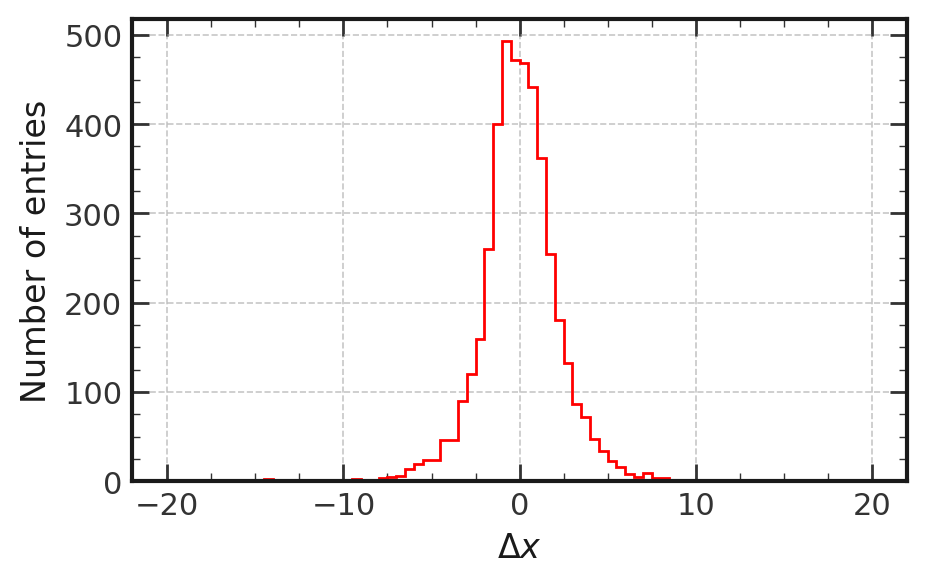

In [57]:
plt.hist(dx_arr,bins=80,range=(-20,20),histtype='step',color='red')
plt.ylabel('Number of entries')
plt.xlabel(r'$ \Delta x$')
plt.savefig(plot_dir + "dx_dist_mx2.png",bbox_inches='tight')
plt.savefig(plot_dir + "dx_dist_mx2.pdf",bbox_inches='tight')
plt.show()

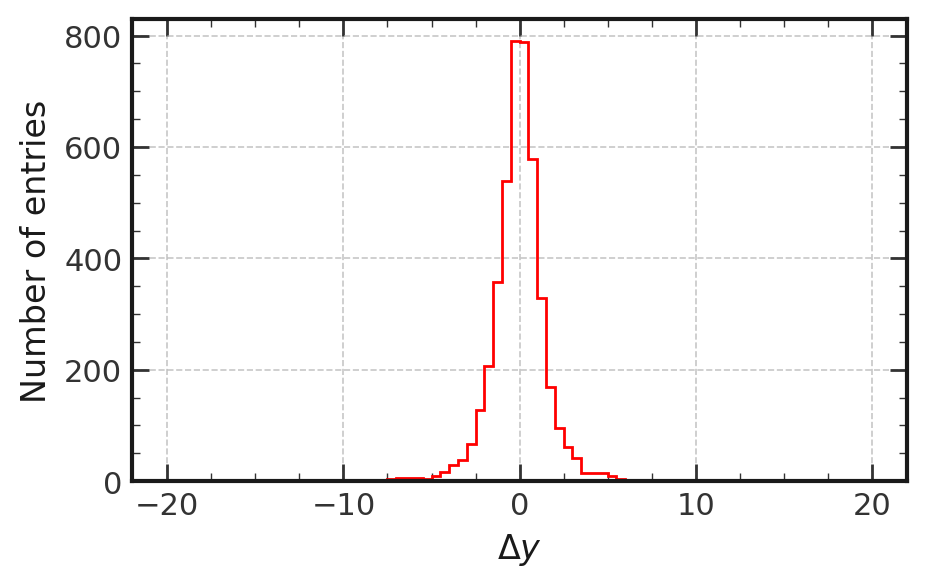

In [58]:
plt.hist(dy_arr,bins=80,range=(-20,20),histtype='step',color='red')
plt.ylabel('Number of entries')
plt.xlabel(r'$ \Delta y$')
plt.savefig(plot_dir + "dy_dist_mx2.png",bbox_inches='tight')
plt.savefig(plot_dir + "dy_dist_mx2.pdf",bbox_inches='tight')
plt.show()

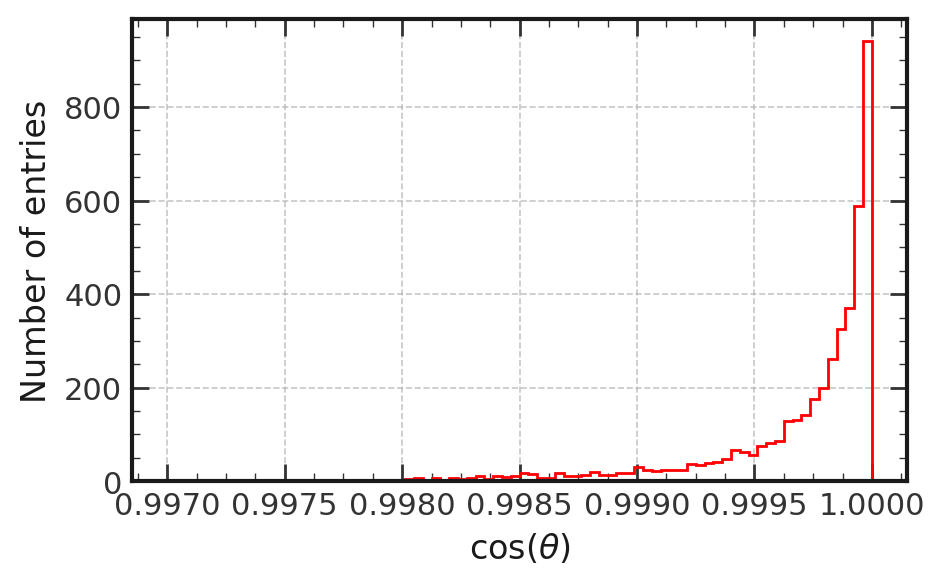

In [59]:
plt.hist(dp_arr,bins=80,range=(0.997,1.0),histtype='step',color='red')
plt.ylabel('Number of entries')
plt.xlabel(r'cos($ \theta $)')
plt.savefig(plot_dir + "dir_dist_mx2.png",bbox_inches='tight')
plt.savefig(plot_dir + "dir_dist_mx2.pdf",bbox_inches='tight')
plt.show()